#### Jon Krenick Z23674518      							
#### Sydney Durrance Z23601407

# Hypotheses

## A. T-Tests

**1. BMI by Diabetes Status**
- H₀: There is no difference in mean BMI between individuals with diabetes and individuals without diabetes.
- Hₐ: There is a difference in mean BMI between individuals with diabetes and individuals without diabetes.

**2. BMI by High Blood Pressure Status**
- H₀: There is no difference in mean BMI between individuals with high blood pressure and individuals without high blood pressure.
- Hₐ: There is a difference in mean BMI between individuals with high blood pressure and individuals without high blood pressure.

## B. Chi-Square Tests

**3. Diabetes Status and Sex**
- H₀: Diabetes status and sex are independent.
- Hₐ: Diabetes status and sex are associated.

**4. Diabetes Status and Stroke History**
- H₀: Diabetes status and stroke history are independent.
- Hₐ: Diabetes status and stroke history are associated.

## C. Linear Regression

**5. Physical Activity and BMI**
- Main independent variable: Physical Activity
- Control variables: Sex, Age
- H₀: Physical activity is not associated with BMI, controlling for sex and age.
- Hₐ: Physical activity is negatively associated with BMI, controlling for sex and age.

**6. Daily Fruit Consumption and BMI**
- Main independent variable: Daily Fruit Consumption
- Control variables: Income Group, Education Group
- H₀: Daily fruit consumption is not associated with BMI, controlling for income and education.
- Hₐ: Daily fruit consumption is negatively associated with BMI, controlling for income and education.

In [21]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
import pingouin as pg
import statsmodels.api as sm

In [22]:
df = pd.read_csv('../Data/data_cleaned.csv')

df.head()

,Diabetes,HighBloodPressure,HighCholesterol,CholesterolCheck,BMI,Smoker,Stroke,HeartDiseaseOrAttack,PhysicalActivity,EatsFruitsDaily,...,Education,Income,GeneralHealthGroup,MentalHealthDaysGroup,PhysicalHealthDaysGroup,BMIGroup,SexLabel,AgeGroup,EducationGroup,IncomeGroup
0,0,1,1,1,40.0,1,0,0,0,0,...,4,3,Poor,Frequent Days,Frequent Days,Class 3 Obesity,Female,60-64,High School Graduate or GED,"$15,000 to <$20,000"
1,0,0,0,0,25.0,1,0,0,1,0,...,6,1,Good,No Days,No Days,Overweight,Female,50-54,College Graduate,"Less than $10,000"
2,0,1,1,1,28.0,0,0,0,0,1,...,4,8,Poor,Frequent Days,Frequent Days,Overweight,Female,60-64,High School Graduate or GED,"$75,000+"
3,0,1,0,1,27.0,0,0,0,1,1,...,3,6,Very Good,No Days,No Days,Overweight,Female,70-74,Completed Grades 9 through 11,"$35,000 to <$50,000"
4,0,1,1,1,24.0,0,0,0,1,1,...,5,4,Very Good,Some Days,No Days,Healthy Weight,Female,70-74,Some College or Technical School,"$20,000 to <$25,000"


### T-Test

In [23]:
df_diabetes_yes = df[df['Diabetes'] == 1]
df_diabetes_no = df[df['Diabetes'] == 0]

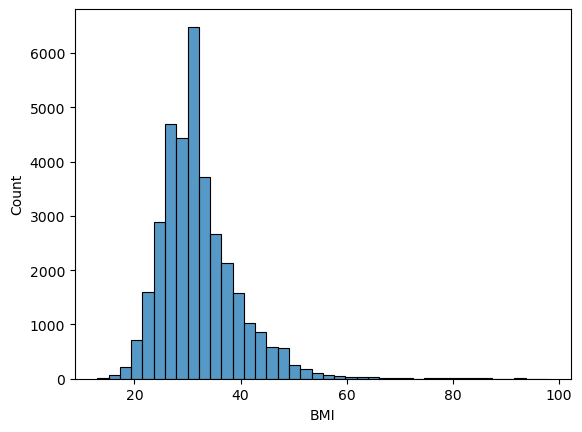

In [24]:
sns.histplot(
    data = df_diabetes_yes,
    x = 'BMI',
    bins = 40
);

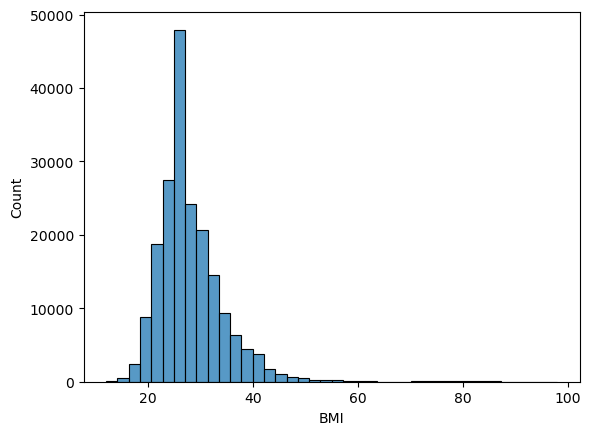

In [25]:
sns.histplot(
    data = df_diabetes_no,
    x = 'BMI',
    bins = 40
);

The data distributions for both groups (diabetes and no diabetes) are unimodal but right-skewed with a tail trailing toward the higher BMI values. This tells us that the BMI distribution is not a normal distribution for either of the two groups. This would make a t-test not appropriate for this experiment. However, because we have a very large sample size, the Central Limit Theorem ensures that the sampling distribution of the mean is approximately normal regardless of the skew in the data distribution, making a t-test valid in this scenario.

Src: https://journals.physiology.org/doi/full/10.1152/advan.00064.2017

In [26]:
ttest1 = ttest_ind(
    df_diabetes_yes['BMI'],
    df_diabetes_no['BMI']
)

print(f"Test Statistic: {ttest1[0]}")
print(f"P-value: {ttest1[1]}")

Test Statistic: 100.37641748073698
P-value: 0.0


The t-test above produced a p-value of 0.0 (most likely way too small to represent as it is much smaller than 0.001). This value is well below the significance level of 0.05 telling us the relationship between the two variables is statistically significant. Therefore we have enough evidence to reject the null hypothesis (H0) in favor of our alternative hypothesis (Ha), stating that there is a difference in mean BMI between individuals who have diabetes and individuals who don't have diabetes.

In [27]:
df_highbloodpressure_yes = df[df['HighBloodPressure'] == 1]
df_highbloodpressure_no = df[df['HighBloodPressure'] == 0]

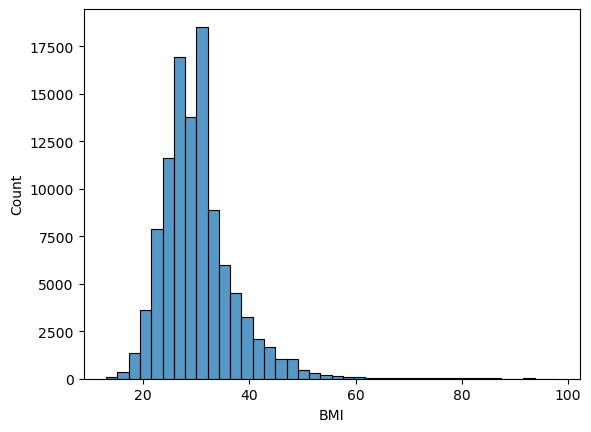

In [28]:
sns.histplot(
    data = df_highbloodpressure_yes,
    x = 'BMI',
    bins = 40
);

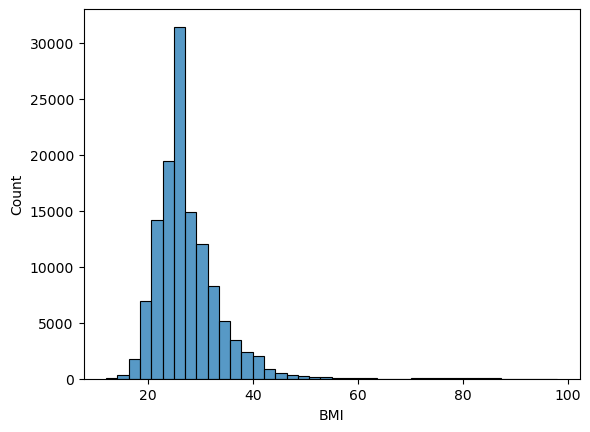

In [29]:
sns.histplot(
    data = df_highbloodpressure_no,
    x = 'BMI',
    bins = 40
);

The data distributions for both groups (high blood pressure and no high blood pressure) are unimodal but right-skewed with a tail trailing toward the higher BMI values. This tells us that the BMI distribution is not a normal distribution for either of the two groups. This would make a t-test not appropriate for this experiment. However, because we have a very large sample size, the Central Limit Theorem ensures that the sampling distribution of the mean is approximately normal regardless of the skew in the data distribution, making a t-test valid in this scenario.

Src: https://journals.physiology.org/doi/full/10.1152/advan.00064.2017

In [30]:
ttest2 = ttest_ind(
    df_highbloodpressure_yes['BMI'],
    df_highbloodpressure_no['BMI']
)

print(f"Test Statistic: {ttest2[0]}")
print(f"P-value: {ttest2[1]}")

Test Statistic: 94.84288200487728
P-value: 0.0


The t-test above produced a p-value of 0.0 (most likely way too small to represent as it is much smaller than 0.001). This value is well below the significance level of 0.05 telling us the relationship between the two variables is statistically significant. Therefore we have enough evidence to reject the null hypothesis (H0) in favor of our alternative hypothesis (Ha), stating that there is a difference in mean BMI between individuals who have high blood pressure and individuals who don't have high blood pressure.

### Chi-Square

In [31]:
observations1 = pd.crosstab(index=df["Diabetes"], columns=df["Sex"], margins = False)

observations1

Sex,0,1
Diabetes,,
0,110370,84007
1,18345,16752


In [43]:
chi2, p, dof, ex = chi2_contingency(observations1)

print(f"Chi2: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected: {ex}")

Chi2: 245.55384122428245
P-value: 2.419783945499187e-55
Degrees of Freedom: 1
Expected: [[109028.62875533  85348.37124467]
 [ 19686.37124467  15410.62875533]]


The chi-square test above produced a $\chi^2$ value of 245.55 with one degree of freedom and a p-value of $2.4e^{-55}$. Since the p-value is far below the significance level of 0.05, we can conclude that there is a statistically significant relationship between the two variables. Therefore, we can reject the null hypothesis (H0) in favor of the alternative hypothesis (Ha) that states diabetes status and sex are associated with one another.

In [33]:
observations2 = pd.crosstab(index=df["Diabetes"], columns=df["Stroke"], margins = False)

observations2

Stroke,0,1
Diabetes,,
0,187361,7016
1,31829,3268


In [34]:
chi2, p, dof, ex = chi2_contingency(observations2)

print(f"Chi2: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected: {ex}")

Chi2: 2256.534054854552
P-value: 0.0
Degrees of Freedom: 1
Expected: [[185665.89081988   8711.10918012]
 [ 33524.10918012   1572.89081988]]


The chi-square test above produced a $\chi^22$ value of 2256.53 with one degree of freedom and a p-value of 0.0 (most likely too small to represent being less than 0.001). Since the p-value is far below the significance level of 0.05, we can conclude that there is a statistically significant relationship between the two variables. Therefore, we can reject the null hypothesis (H0) in favor of the alternative hypothesis (Ha) that states diabetes status and history of stroke are associated with one another.

### Linear Regression

### Model 1
- **Dependent Variable** - BMI
- **Independent Variable** - PhysicalActivity
- **Control Variables** - Sex, Age

In [44]:
X = df[['PhysicalActivity', 'Sex', 'Age']]
y = df['BMI']

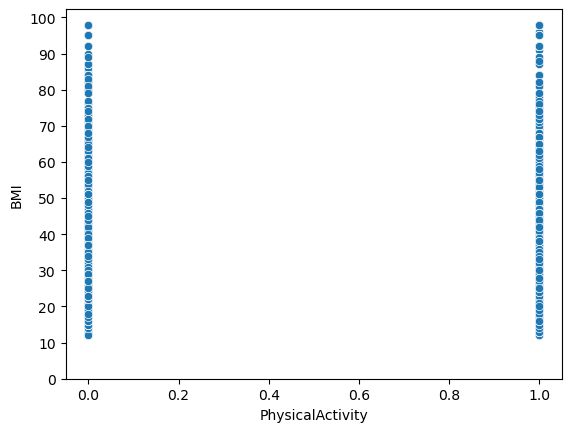

In [54]:
sns.scatterplot(
    df,
    x = 'PhysicalActivity',
    y = 'BMI',
);

plt.yticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
plt.show()

Because the independent variable (PhysicalActivity) is a binary variable, the scatterplot shows two vertical bands of points at x = 0 and x = 1 rather than a continuous distribution of the data points. Both bands span a wide range of BMI values, so the direction of the relationship is difficult to judge from the visual alone. However, the band of BMI values where x = 0 appears to be more concentrated at the higher end of BMI values in comparison to the band where x = 1, suggesting a negative relationship between the two variables, with physically active people tending to have lower BMI values. We can confirm the relationship once we see the coefficient from the regression model.

In [45]:
model1 = pg.linear_regression(
    X, y
)

model1

,names,coef,se,T,pval,r2,adj_r2,CI2.5,CI97.5
0,Intercept,31.059173,0.049064,633.038982,0.000000e+00,0.02113,0.021117,30.963009,31.155336
1,PhysicalActivity,-2.059155,0.031836,-64.679586,0.000000e+00,0.02113,0.021117,-2.121553,-1.996756
2,Sex,0.458135,0.028283,16.198396,5.582034e-59,0.02113,0.021117,0.402702,0.513569
3,Age,-0.131524,0.004551,-28.900376,2.525305e-183,0.02113,0.021117,-0.140444,-0.122604


The coefficient for PhysicalActivity (our independent variable) is -2.06, which confirms our speculation that the relationship between the two variables was negative. Individuals who are physically active have a BMI about 2.06 units lower on average than inactive individuals, holding sex and age constant. Looking at the p-value for this variable, we see a value of 0.00 (too small to represent), telling us that the relationship between our independent and dependent variable is statistically significant. Therefore, we are able to reject the null hypothesis (H0) in favor of our alternative hypothesis (Ha) which states that physical activity is negatively associated with BMI.

Looking at our control variables, Sex has a coefficient of 0.46 and Age has a coefficient of -0.13. This tells us that on average, males on average have about 0.46 BMI units higher than females after accounting for physical activity and age and that on average, BMI decreases about 0.13 units per age bracket, with older age brackets leaning towards lower BMI. Looking at the p-values for these two variables, Sex has a p-value of $5.58e^{-59}$ and Age has a p-value of $2.53e^{-183}$, which tells us that both control variables are statistically significant.

The R^2 value for this model is 0.02113, telling us that the model explains about 2.1% of the variation in our dependent variable (BMI). While physical activity, age, and sex are all statistically significant predictors, together they only account for a very small share of why BMI differs across individuals. This tells us that the model has very little power to predict any single individual's BMI as the model simply does not explain enough of the variation that occurs in the dataset. This is a great example of how statistical significance and explanatory power tell different stories within the same regression model.

### Model 2
- **Dependent Variable** - BMI
- **Independent Variable** - EatsFruitsDaily
- **Control Variables** - Income Group, Education Group

In [49]:
income_dummies = pd.get_dummies(
    df['IncomeGroup'],
    prefix = 'Income',
    drop_first = True,
    dtype = int
)

education_dummies = pd.get_dummies(
    df['EducationGroup'],
    prefix = 'Education',
    drop_first = True,
    dtype = int
)

X = pd.concat([
    df['EatsFruitsDaily'],
    income_dummies,
    education_dummies
], axis = 1)

y = df['BMI']

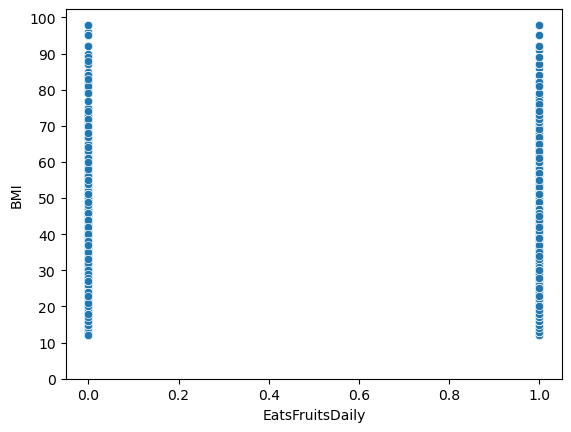

In [55]:
sns.scatterplot(
    df,
    x = 'EatsFruitsDaily',
    y = 'BMI'
);

plt.yticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
plt.show()

Similarly to model 1, because the independent variable (EatsFruitsDaily) os a binary variable, the scatterplot shows two vertical bands rather than a continuous distribution of the data, making the direction of the relationship hard to determine from the scatterplot alone. If anything, extreme BMI values look slightly denser in the group that does not eat fruit daily, hinting at a negative relationship. The regression model is needed to quantify the direction and strength of the association.

In [50]:
model2 = pg.linear_regression(
    X, y
)

model2

,names,coef,se,T,pval,r2,adj_r2,CI2.5,CI97.5
0,Intercept,29.485156,0.070893,415.913241,0.000000e+00,0.012376,0.01232,29.346208,29.624103
1,EatsFruitsDaily,-0.838621,0.029048,-28.870307,6.006561e-183,0.012376,0.01232,-0.895554,-0.781688
2,"Income_$15,000 to <$20,000",-0.491510,0.082087,-5.987637,2.132265e-09,0.012376,0.01232,-0.652399,-0.330621
3,"Income_$20,000 to <$25,000",-0.685293,0.078655,-8.712597,2.989107e-18,0.012376,0.01232,-0.839455,-0.531130
4,"Income_$25,000 to <$35,000",-0.791325,0.075771,-10.443626,1.587889e-25,0.012376,0.01232,-0.939835,-0.642816
5,"Income_$35,000 to <$50,000",-0.763572,0.072849,-10.481537,1.064376e-25,0.012376,0.01232,-0.906354,-0.620789
6,"Income_$50,000 to <$75,000",-0.790094,0.072207,-10.942065,7.368885e-28,0.012376,0.01232,-0.931618,-0.648570
7,"Income_$75,000+",-1.159581,0.069645,-16.649939,3.295418e-62,0.012376,0.01232,-1.296083,-1.023079
8,"Income_Less than $10,000",-0.099533,0.092415,-1.077023,2.814713e-01,0.012376,0.01232,-0.280664,0.081598
9,Education_Completed Grades 1 through 8,0.879825,0.111738,7.874022,3.449063e-15,0.012376,0.01232,0.660822,1.098828


Looking at our independent variable, EatsFruitsDaily has a coefficient of -0.84, telling us that the relationship between the main independent variable and dependent variable is in fact negative (as predicted). This tells us that individuals who eat fruit at least once per day have an average BMI of about 0.84 units lower than those who do not, holding income and education constant. Looking at the p-value, EatsFruitsDaily has a value of $6.01e^{-183}$, telling us that the relationship between our dependent and main independent variable is statistically significant. Therefore, we can reject the null hypothesis (H0) in favor of the alternative hypothesis (Ha) which says daily fruit consumption is negatively associated with BMI.

Looking at our control variables, the income dummies have negative coefficients relative to the 10,000 to <15,000 baseline income group, ranging from about -0.49 for the 15,000 to <20,000 group down to -1.16 for the 75,000+ group. This tells us that individuals in higher income groups have a lower average BMI than the baseline group, holding fruit consumption and education constant. Looking at the p-values, all of the income groups have values below 0.001 except for the "Less than 10,000" group, which has a value of 0.28, telling us that all income groups are statistically significant except for the "Less than 10,000" group, which is not statistically different from the baseline.

Looking at the education dummies, every group below a four-year degree has a positive coefficient relative to the college graduate baseline group, ranging from about +0.80 for high school graduates to +1.31 for those who never attended school. This tells us that individuals with less education have a higher average BMI than college graduates, holding fruit consumption and income constant. Looking at the p-values, all of the education groups have values below 0.05, telling us that the relationship between each education group and BMI is statistically significant.

The R^2 value for this model is 0.012376, telling us that the model explains about 1.2% of the variation in our dependent variable (BMI). While daily fruit consumption and nearly all of the income and education groups are statistically significant predictors, together they only account for a very small share of why BMI differs across individuals. This tells us that the model has very little power to predict any single individual's BMI as the model simply does not explain enough of the variation that occurs in the dataset. Just like the first model, this is another example of how statistical significance and explanatory power tell different stories within the same regression model.